nama    : kemas muhammad irfan
kelas   : robotika malam A
NIM     :4222311014


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [18]:
os.makedirs("results", exist_ok=True)

In [19]:
print("Loading dataset...")

csv_path = "emnist-letters-train.csv"

data = pd.read_csv(csv_path, header=None)

print("Dataset loaded successfully")
print("Original dataset shape:", data.shape)

data.head()

Loading dataset...
Dataset loaded successfully
Original dataset shape: (88800, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
balanced_data = []

for label in range(1, 27):
    class_samples = data[data[0] == label]

    sampled = class_samples.sample(
        n=100,
        random_state=42
    )

    balanced_data.append(sampled)

balanced_data = pd.concat(balanced_data)

balanced_data = balanced_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced dataset created")
print("Total samples:", len(balanced_data))

balanced_data.head()

Balanced dataset created
Total samples: 2600


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
labels = balanced_data.iloc[:, 0].values
images = balanced_data.iloc[:, 1:].values

print("Label shape:", labels.shape)
print("Image shape:", images.shape)

Label shape: (2600,)
Image shape: (2600, 784)


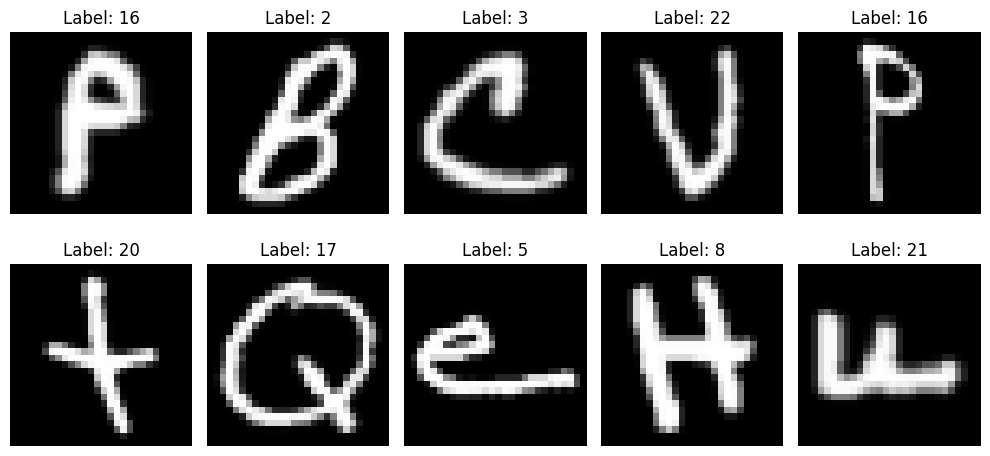

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].reshape(28, 28)

    img = np.transpose(img)

    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("results/sample_dataset.png")
plt.show()

In [23]:
print("Extracting HOG features...")

hog_features = []

for img in images:
    img = img.reshape(28, 28)

    img = np.transpose(img)

    img = img / 255.0

    feature = hog(
        img,
        orientations=12,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    hog_features.append(feature)

X = np.array(hog_features)
y = np.array(labels)

print("HOG extraction completed")
print("Feature shape:", X.shape)

Extracting HOG features...
HOG extraction completed
Feature shape: (2600, 192)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2080
Testing samples: 520


In [25]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [26]:
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

In [27]:
train_accuracy = accuracy_score(y_train, y_train_pred)

train_precision = precision_score(
    y_train,
    y_train_pred,
    average='weighted',
    zero_division=0
)

train_recall = recall_score(
    y_train,
    y_train_pred,
    average='weighted',
    zero_division=0
)

train_f1 = f1_score(
    y_train,
    y_train_pred,
    average='weighted',
    zero_division=0
)

print("===== TRAINING RESULT =====")
print(f"Accuracy  : {train_accuracy:.4f}")
print(f"Precision : {train_precision:.4f}")
print(f"Recall    : {train_recall:.4f}")
print(f"F1-Score  : {train_f1:.4f}")

===== TRAINING RESULT =====
Accuracy  : 0.9990
Precision : 0.9990
Recall    : 0.9990
F1-Score  : 0.9990


In [28]:
test_accuracy = accuracy_score(y_test, y_test_pred)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

print("===== TESTING RESULT =====")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-Score  : {test_f1:.4f}")

===== TESTING RESULT =====
Accuracy  : 0.7596
Precision : 0.7661
Recall    : 0.7596
F1-Score  : 0.7601


In [29]:
train_report = classification_report(y_train, y_train_pred)
test_report = classification_report(y_test, y_test_pred)

print("TRAIN REPORT")
print(train_report)

print("TEST REPORT")
print(test_report)

TRAIN REPORT
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        80
           2       1.00      1.00      1.00        80
           3       1.00      1.00      1.00        80
           4       1.00      1.00      1.00        80
           5       1.00      1.00      1.00        80
           6       1.00      1.00      1.00        80
           7       1.00      1.00      1.00        80
           8       1.00      1.00      1.00        80
           9       0.99      0.99      0.99        80
          10       1.00      1.00      1.00        80
          11       1.00      1.00      1.00        80
          12       0.99      0.99      0.99        80
          13       1.00      1.00      1.00        80
          14       1.00      1.00      1.00        80
          15       1.00      1.00      1.00        80
          16       1.00      1.00      1.00        80
          17       1.00      1.00      1.00        80
          18  

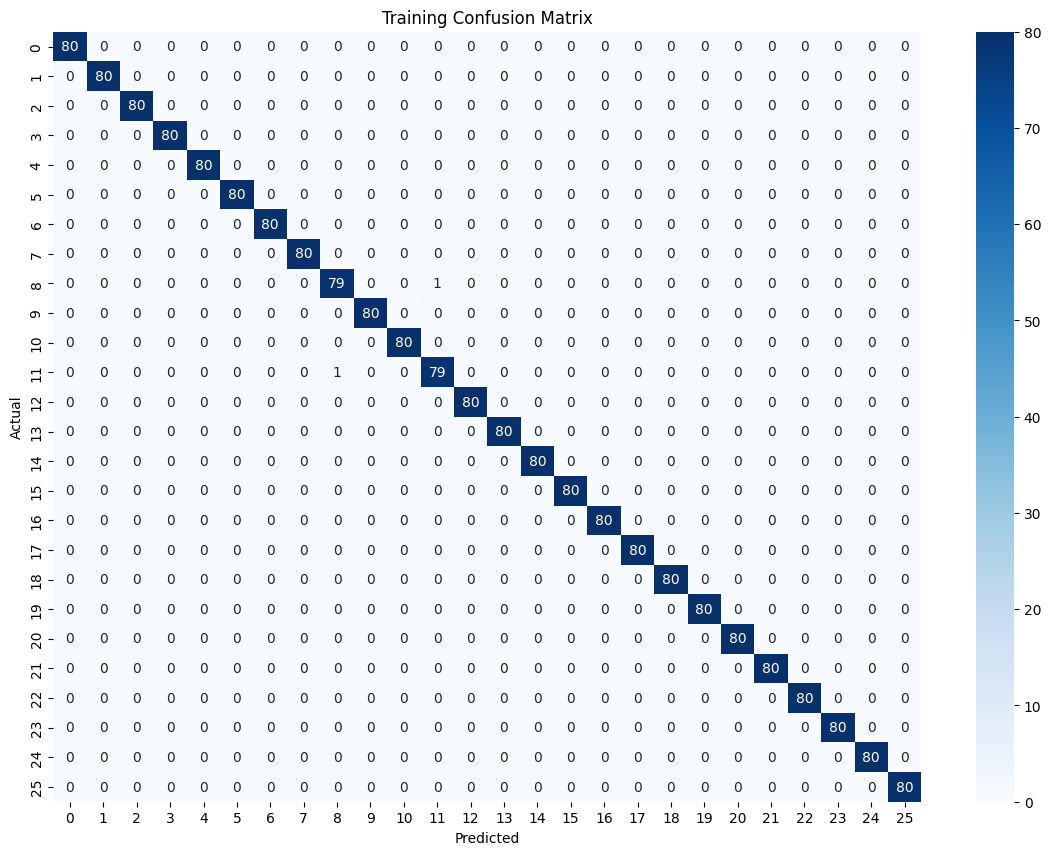

In [30]:
cm_train = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(14,10))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')

plt.title("Training Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

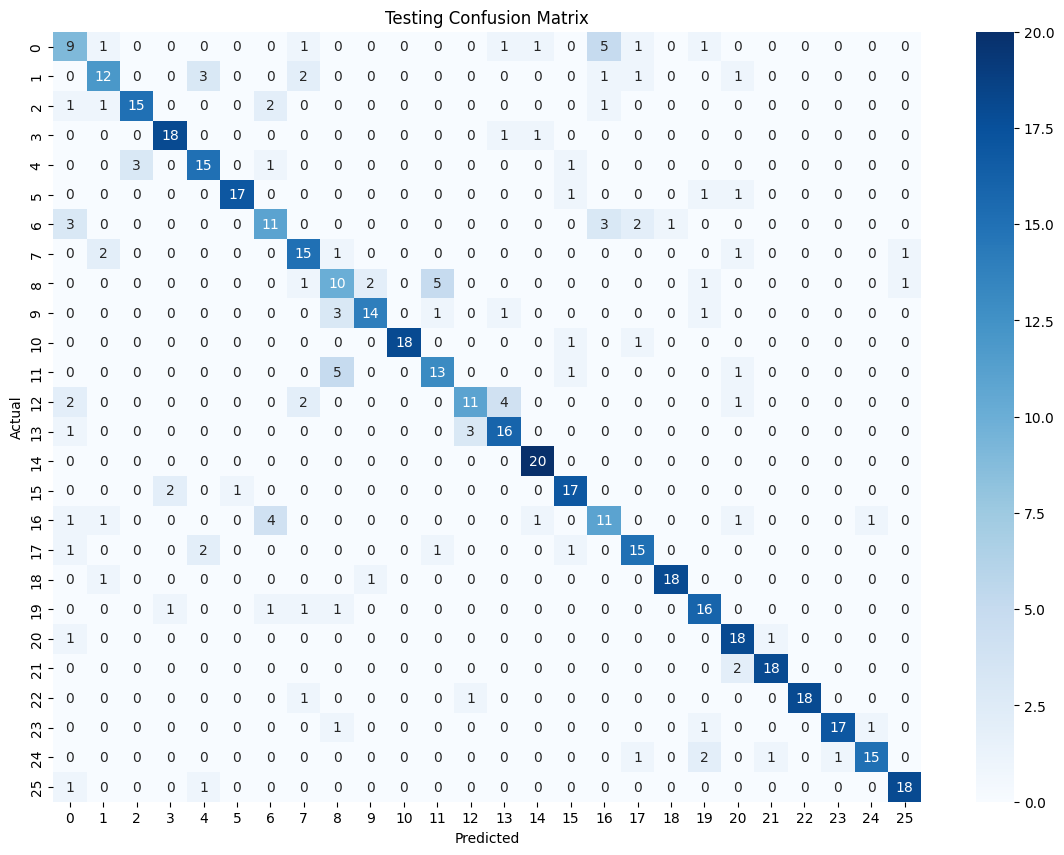

In [31]:
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(14,10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')

plt.title("Testing Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
with open("results/summary_result.txt", "w") as f:
    f.write("===== TRAINING RESULT =====\n")
    f.write(f"Accuracy  : {train_accuracy:.4f}\n")
    f.write(f"Precision : {train_precision:.4f}\n")
    f.write(f"Recall    : {train_recall:.4f}\n")
    f.write(f"F1-Score  : {train_f1:.4f}\n\n")

    f.write("===== TESTING RESULT =====\n")
    f.write(f"Accuracy  : {test_accuracy:.4f}\n")
    f.write(f"Precision : {test_precision:.4f}\n")
    f.write(f"Recall    : {test_recall:.4f}\n")
    f.write(f"F1-Score  : {test_f1:.4f}\n")

print("All results saved successfully!")

All results saved successfully!


## Kesimpulan

Model HOG + SVM berhasil digunakan untuk klasifikasi huruf tulisan tangan pada dataset EMNIST.
Parameter terbaik diperoleh menggunakan Grid Search sehingga performa model meningkat.
